# DP Wizard ouput example

[DP Wizard](https://github.com/opendp/dp-wizard) makes it easier to get started with differential privacy.
DP Wizard demonstrates how to calculate DP statistics or create a synthetic dataset from the data you provide.
This notebook is an example of DP Wizard output, running on the built-in demo dataset.

----

# DP Statistics for `grade` grouped by `class_year_str`

This demonstrates how to calculate DP Statistics for `grade` grouped by `class_year_str` using OpenDP (https://docs.opendp.org).
Generated by DP Wizard v0.10.0 (https://github.com/opendp/dp-wizard) on Aug 14, 2026 at 04:09PM.

- Privacy Budget (Epsilon) = 2.0
- Maximum of 10 rows per individual
- Columns:
    - student_id (Integer): Not used
    - class_year_str (String): "first year", "sophomore", "junior", "senior"
    - hw_number (Integer): Not used
    - grade (Integer): Histogram clipped to 50.0-100.0
    - self_assessment (Integer): Not used

Jump ahead:
- [Analysis](#Analysis)
- [Results](#Results)

## Prerequisites

In [1]:
import matplotlib.pyplot as plt
import opendp.prelude as dp
import polars as pl

# The OpenDP team is working to vet the core algorithms.
# Until that is complete we need to opt-in to use these features.
dp.enable_features("contrib")

Then define some utility functions to handle dataframes and plot results:

In [2]:
def round_2(number) -> float:
    """
    >>> round_2(1234)
    1200.0
    >>> round_2(0.001234)
    0.0012
    """
    return float(f"{number:.2g}")


def make_cut_points(
    lower_bound: float, upper_bound: float, bin_count: int
) -> list[float]:
    """
    Returns one more cut point than the bin_count,
    with the cut points rounded to two decimal places
    (There are actually two more bins, extending to
    -inf and +inf, but we'll ignore those.)

    Cut points are evenly spaced from lower_bound to upper_bound,

    >>> make_cut_points(0, 10, 2)
    [0.0, 5.0, 10.0]
    >>> make_cut_points(-1, 1, 4)
    [-1.0, -0.5, 0.0, 0.5, 1.0]

    Will return fewer points than requested if cut points
    only differ in later decimal places.

    >>> make_cut_points(1, 1.01, 4)
    [1.0]
    """
    bin_width = (upper_bound - lower_bound) / bin_count
    # Duplicate values would cause an error in Polars.
    # Use a set to return unique values.
    return sorted({round_2(lower_bound + i * bin_width) for i in range(bin_count + 1)})


# These functions are used both in the application
# and in generated notebooks.
from polars import DataFrame


def get_interval_bottom(interval: str) -> float:
    """
    >>> get_interval_bottom("(10, 20]")
    10.0
    >>> get_interval_bottom("-10")
    -10.0
    >>> get_interval_bottom("unexpected")
    0.0
    """
    # Intervals from Polars default to open on the left,
    # so that's the only case we cover with replace().
    try:
        return float(interval.split(",")[0].replace("(", ""))
    except ValueError:
        return 0.0


delim = "; "


def get_group(merged):
    """
    >>> get_group("value")
    ''
    >>> get_group("group 1; value")
    'group 1'
    >>> get_group("group 1; group 2; value")
    'group 1; group 2'
    """
    return delim.join(merged.split(delim)[:-1])


def df_to_columns(df: DataFrame):
    """
    Transform a Dataframe into a format that is easier to plot,
    parsing the interval strings to sort them as numbers.
    """
    merged_key_rows = [
        (delim.join(str(k) for k in keys), value) for (*keys, value) in df.rows()
    ]
    sorted_rows = sorted(merged_key_rows, key=lambda row: get_interval_bottom(row[0]))
    transposed = tuple(zip(*sorted_rows))
    return transposed if transposed else ((), ())


def plot_bars(df: DataFrame, title: str, error: float = 0):  # pragma: no cover
    """
    Given a Dataframe, make a bar plot of the data in the last column,
    with labels from the prior columns.
    """

    plt.rcParams["figure.figsize"] = (12, 4)

    bins, values = df_to_columns(df)
    _figure, axes = plt.subplots()
    top_bins = list({get_group(b) for b in bins})
    cmap = plt.cm.tab10  # pyright: ignore[reportAttributeAccessIssue]
    bar_colors = [cmap(top_bins.index(get_group(b)) % cmap.N) for b in bins]
    axes.bar(bins, values, color=bar_colors, yerr=error)
    axes.set_xticks(bins, bins, rotation=45)
    axes.set_ylim(bottom=0)
    axes.set_title(title)

## Analysis

Based on the input you provided, for each column we'll create a Polars expression
that describes how we want to summarize that column.

### Expression for `grade`

In [3]:

# See the OpenDP Library docs for more on making private histograms:
# https://docs.opendp.org/en/v0.14.2/getting-started/tabular-data/grouping.html

# Use the public information to make cut points for 'grade':
grade_cut_points = make_cut_points(
    lower_bound=50.0,
    upper_bound=100.0,
    bin_count=5,
)

# Use these cut points to add a new binned column to the table:
grade_bin_expr = (
    pl.col("grade")
    .cut(grade_cut_points)  # Use "left_closed=True" to switch endpoint inclusion.
    .alias("grade_bin")  # Give the new column a name.
    .cast(pl.String)
)

### Context

Next, we'll define our Context. This is where we set the privacy budget,
and set the weight for each query under that overall budget.

In [4]:
# Each individual can contribute this many rows.
contributions = 10
privacy_unit = dp.unit_of(contributions=contributions)
privacy_loss = dp.loss_of(
    #
    # Your privacy budget is captured in the "epsilon" parameter.
    # Larger values increase the risk that personal data could be
    # reconstructed, so choose the smallest value that gives you
    # the needed accuracy. You can also compare your budget to
    # other projects:
    # https://registry.opendp.org/deployments-registry/
    #
    epsilon=2.0,
    # Not necessary in this case,
    # but other analyses require a very small "delta" value.
    # https://docs.opendp.org/en/v0.14.2/getting-started/tabular-data/grouping.html#Stable-Keys
    delta=0,  # or 1 / max(1e7, 1000),
)

import csv
import random
from pathlib import Path


def _clip(n: float, lower_bound: float, upper_bound: float) -> float:
    """
    >>> _clip(-5, 0, 10)
    0
    >>> _clip(5, 0, 10)
    5
    >>> _clip(15, 0, 10)
    10
    """
    return max(min(n, upper_bound), lower_bound)


def make_demo_csv(path: Path, contributions: int) -> None:
    """
    >>> import tempfile
    >>> from pathlib import Path
    >>> import csv
    >>> with tempfile.NamedTemporaryFile() as temp:
    ...     make_demo_csv(Path(temp.name), 10)
    ...     with open(temp.name, newline="") as csv_handle:
    ...         reader = csv.DictReader(csv_handle)
    ...         reader.fieldnames
    ...         rows = list(reader)
    ...         rows[0].values()
    ...         rows[-1].values()
    ['student_id', 'class_year_str', 'hw_number', 'grade', 'self_assessment']
    dict_values(['1', 'sophomore', '1', '82', '0'])
    dict_values(['100', 'sophomore', '10', '78', '0'])
    """
    random.seed(0)  # So the mock data will be stable across runs.
    with path.open("w", newline="") as demo_csv_handle:
        fields = [
            "student_id",
            "class_year_str",
            "hw_number",
            "grade",
            "self_assessment",
        ]
        class_year_map = ["first year", "sophomore", "junior", "senior"]
        writer = csv.DictWriter(demo_csv_handle, fieldnames=fields)
        writer.writeheader()
        for student_id in range(1, 101):
            class_year = int(_clip(random.gauss(1, 1), 0, 3))
            for hw_number in range(1, contributions + 1):
                # Older students do slightly better in the class,
                # but each assignment gets harder.
                mean_grade = random.gauss(90, 5) + (class_year + 1) * 2 - hw_number
                grade = int(_clip(random.gauss(mean_grade, 5), 0, 100))
                self_assessment = 1 if grade > 90 and random.random() > 0.1 else 0
                writer.writerow(
                    {
                        "student_id": student_id,
                        "class_year_str": class_year_map[class_year],
                        "hw_number": hw_number,
                        "grade": grade,
                        "self_assessment": self_assessment,
                    }
                )


make_demo_csv(Path("/tmp/demo.csv"), 10)

# See the OpenDP Library docs for more on Context:
# https://docs.opendp.org/en/v0.14.2/api/user-guide/context/index.html#context
stats_context = dp.Context.compositor(
    data=pl.scan_csv(
        "/tmp/demo.csv", encoding="utf8-lossy", ignore_errors=True
    ).with_columns(grade_bin_expr),
    privacy_unit=privacy_unit,
    privacy_loss=privacy_loss,
    split_by_weights=[  # With only one query, the entire budget is allocated to that query:
        1,  # grade
    ],
    margins=[  # "max_partition_length" should be a loose upper bound,
        # for example, the size of the total population being sampled.
        # https://docs.opendp.org/en/v0.14.2/api/python/opendp.extras.polars.html#opendp.extras.polars.Margin.max_partition_length
        #
        # In production, "max_groups" should be set by considering
        # the number of possible values for each grouping column,
        # and taking their product.
        dp.polars.Margin(
            by=list(
                {
                    "class_year_str": ["first year", "sophomore", "junior", "senior"]
                }.keys()
            ),
            max_length=1000,
            max_groups=100,
        ),
        dp.polars.Margin(
            by=(
                ["grade_bin"]
                + list(
                    {
                        "class_year_str": [
                            "first year",
                            "sophomore",
                            "junior",
                            "senior",
                        ]
                    }.keys()
                )
            ),
            invariant="keys",  # Consider the bin values to be public information.
        ),
    ],
)


A note on `utf8-lossy`: CSVs can use different "character encodings" to
represent characters outside the ASCII character set, but out-of-the-box
the Polars library only supports UTF8. Specifying `utf8-lossy` preserves as
much information as possible, and any unrecognized characters will be replaced
by "�". If this is not sufficient, you will need to preprocess your data to
reencode it as UTF8.

We suggest using `ignore_errors=True`. Runtime errors that depend on a single
value would leak information and violate the DP guarantee,
so it is safer to ignore them. That said, if a significant number of records
are ignored because of errors, it will bias results.

## Results

Finally, we run the queries and plot the results.

In [5]:
confidence = 0.95  # 95% confidence interval

### Query for `grade`:

In [6]:
groups = ["grade_bin"] + ["class_year_str"]
grade_query = (
    stats_context.query()
    .group_by(groups)
    .agg(pl.len().dp.noise().alias("count"))
    .with_keys(
        pl.LazyFrame(
            {"class_year_str": ["first year", "sophomore", "junior", "senior"]}
        )
    )
)

We can summarize the statistic to get the accuracy.
More on [`summarize()` in the OpenDP
docs](https://docs.opendp.org/en/v0.14.2/api/python/opendp.extras.polars.html#opendp.extras.polars.LazyFrameQuery.summarize).

In [7]:
summary = grade_query.summarize(alpha=1 - confidence)
print(summary)

shape: (1, 5)
┌────────┬──────────────┬─────────────────┬───────┬───────────┐
│ column ┆ aggregate    ┆ distribution    ┆ scale ┆ accuracy  │
│ ---    ┆ ---          ┆ ---             ┆ ---   ┆ ---       │
│ str    ┆ str          ┆ str             ┆ f64   ┆ f64       │
╞════════╪══════════════╪═════════════════╪═══════╪═══════════╡
│ count  ┆ Frame Length ┆ Integer Laplace ┆ 5.0   ┆ 15.453703 │
└────────┴──────────────┴─────────────────┴───────┴───────────┘


Proceding to the DP release:

In [8]:
grade_accuracy = summary["accuracy"].item()
grade_stats = grade_query.release().collect()
print(grade_stats)

shape: (14, 3)
┌────────────────┬───────────┬───────┐
│ class_year_str ┆ grade_bin ┆ count │
│ ---            ┆ ---       ┆ ---   │
│ str            ┆ str       ┆ u32   │
╞════════════════╪═══════════╪═══════╡
│ first year     ┆ (60, 70]  ┆ 8     │
│ first year     ┆ (80, 90]  ┆ 256   │
│ sophomore      ┆ (90, 100] ┆ 116   │
│ junior         ┆ (80, 90]  ┆ 51    │
│ sophomore      ┆ (80, 90]  ┆ 175   │
│ …              ┆ …         ┆ …     │
│ first year     ┆ (90, 100] ┆ 144   │
│ senior         ┆ (90, 100] ┆ 60    │
│ junior         ┆ (70, 80]  ┆ 7     │
│ sophomore      ┆ (60, 70]  ┆ 4     │
│ sophomore      ┆ (70, 80]  ┆ 63    │
└────────────────┴───────────┴───────┘


In [9]:
# 95% confidence interval
title = f"DP counts for 'grade', assuming {contributions} contributions per individual"

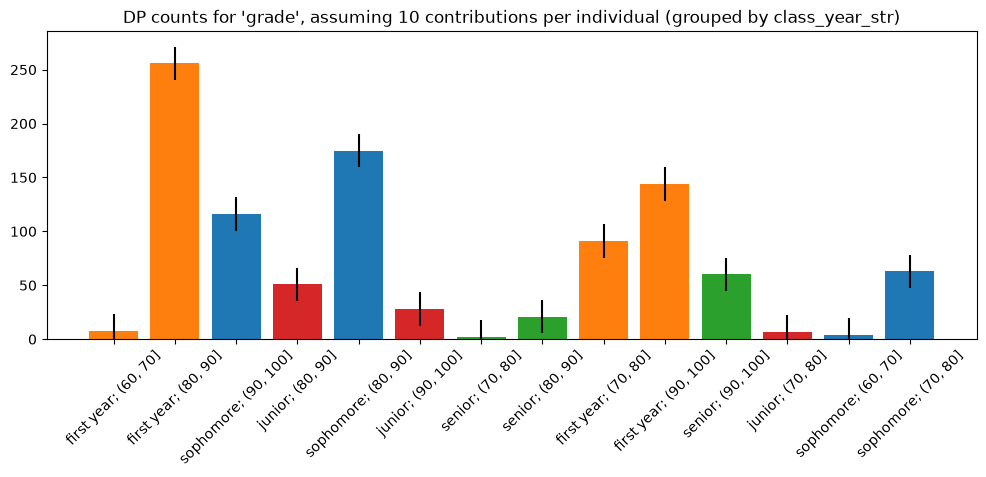

In [10]:
group_names = ["class_year_str"]
if group_names:
    title += f" (grouped by {'/'.join(group_names)})"
plot_bars(grade_stats, title=title, error=grade_accuracy)

`None` values above may indicate strings which could not be converted to numbers.

If we try to run more queries at this point, it will error. Once the privacy budget
is consumed, the library prevents you from running any more queries.